# Visualising Lightning2EarthCARE data collections

This notebook demonstrates how to visualise and explore different Lightning2EarthCARE data collections stored in object storage. It includes examples of loading datasets, selecting subsets of interest, and plotting lightning observations together with EarthCARE-related information.

The project provides three related datasets describing lightning activity in the context of EarthCARE observations:

**1. EarthCARE-frame lightning** – lightning groups collocated with individual EarthCARE MSI-like frames, including activity within the frame and a surrounding 0.5° box within ±1 hour of overpass time.

**2. EarthCARE along-track lightning counts** – lightning statistics referenced to EarthCARE CPR samples along the nadir track, based on counts within defined spatial and temporal windows.

**3. EarthCARE lightning storm catalogue** – lightning clusters sampled along the EarthCARE nadir track by CPR and ATLID, with both cluster-level properties and time-evolving lightning activity around the overpass.

All datasets are distributed as Parquet files, with MTG-LI and GOES-GLM observations provided separately where relevant.

In [1]:
# Imports and storage configuration
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import cartopy.crs as ccrs
from pystac_client import Client
import xarray as xr
import fsspec
from pathlib import Path
import sys

# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

## Exploring lightning storm catalogue

Load the storm catalogue collection from object storage. This collection contains summary information for each identified lightning cluster

In [2]:
lightning_clusters = 'EC_lightning_clusters.parquet'

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{lightning_clusters}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
)

In this example, we select lightning clusters with peak locations in a bounding box covering part of Central Europe. The selected clusters are then ranked by lightning activity along EarthCARE ground track to identify the most active cases for further inspection.

In [3]:
# select area around Central Europe
ceurope_bbox = box(8, 44, 20, 55)
ceurope_gdf = gdf[gdf.geometry.within(ceurope_bbox)].copy()

# sort values according to along track lightning counts and display top 5
ceurope_gdf = ceurope_gdf.sort_values(by="nadir_lightning", ascending=False)
ceurope_gdf.head(5)

,unique_id,earthcare_id,source,parent_cluster_id,cluster_id,surface_type,peak_datetime,peak_lat,peak_lon,peak_lightning,...,cluster_area_km2,cluster_mean_lat,cluster_mean_lon,cluster_dist_km,first_lightning_min,last_lightning_min,duration_min,travel_km,missing_peak_minutes,geometry
2621,05144D_LI_0,05144D,LI,2,0,land,2025-04-24 13:39:25.466299264+00:00,45.287544,11.573071,81,...,300.0,45.294052,11.527297,3.653160,-27,60,88,6.016906,0.0,POINT (11.57307 45.28754)
3472,06280D_LI_22,06280D,LI,141,22,land,2025-07-06 13:49:30.282379392+00:00,45.957253,9.055961,33,...,1200.0,45.899830,9.012404,1.926231,-60,60,121,48.746200,0.0,POINT (9.05596 45.95725)
3500,06311D_LI_3,06311D,LI,24,3,land,2025-07-08 13:38:08.239774464+00:00,46.218311,11.961329,47,...,200.0,46.211014,11.952407,0.495861,-56,60,117,58.542520,0.0,POINT (11.96133 46.21831)
3726,06614B_LI_3,06614B,LI,8,3,coast,2025-07-28 00:36:41.982558464+00:00,45.631767,12.755448,16,...,6450.0,45.296425,12.456554,30.888304,-60,60,121,71.200675,0.0,POINT (12.75545 45.63177)
2969,05564D_LI_2,05564D,LI,20,2,land,2025-05-21 13:27:01.009968512+00:00,48.881435,15.561701,36,...,1000.0,48.877922,15.551656,0.776483,-44,42,87,30.803088,0.0,POINT (15.5617 48.88144)


For the top-ranked storm clusters, we load the corresponding records from the cluster-evolution dataset. This dataset contains the temporal evolution of lightning activity for each cluster, sampled at 1-minute resolution from -60 to +60 minutes relative to the peak time.

In [4]:
top_unique_ids = ceurope_gdf.head(5)["unique_id"].tolist()
selected_file = 'EC_lightning_cluster_evolution.parquet'

evolution_gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    filters=[("unique_id", "in", top_unique_ids)],
)

Plot lightning-count evolution

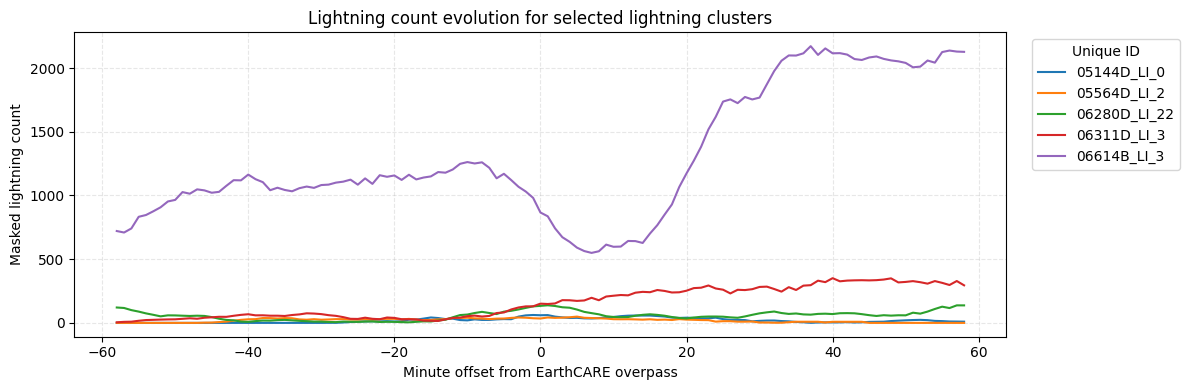

In [5]:
# keep only the columns needed for plotting
plot_df = evolution_gdf[["unique_id", "minute_offset", "masked_lightning_count"]].copy()

# sort for clean line plotting
plot_df = plot_df.sort_values(["unique_id", "minute_offset"])

# centered 5-minute rolling mean
plot_df["masked_lightning_count_smooth"] = (
    plot_df
    .groupby("unique_id")["masked_lightning_count"]
    .transform(lambda s: s.rolling(window=5, center=True, min_periods=5).mean())
)

plt.figure(figsize=(12, 4))

for unique_id, group in plot_df.groupby("unique_id"):
    plt.plot(
        group["minute_offset"],
        group["masked_lightning_count_smooth"],
        label=unique_id,
    )

plt.xlabel("Minute offset from EarthCARE overpass")
plt.ylabel("Masked lightning count")
plt.title("Lightning count evolution for selected lightning clusters")
plt.legend(title="Unique ID", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Plot lightning observations together with EarthCARE data

This example demonstrates how to:
- search and load EarthCARE MSI and CPR products,
- load collocated lightning detections,
- and visualise all datasets together

**Case selection** - we select a specific event by its unique ID for further analysis.

In [6]:
unique_id = "06614B_LI_3"

row = ceurope_gdf.loc[ceurope_gdf["unique_id"] == unique_id].iloc[0]
earthcare_id = row["earthcare_id"]
orbit_number = int(row["earthcare_id"][:-1])
frame = row["earthcare_id"][-1]
cluster_id = row["cluster_id"]
peak_lat = row["peak_lat"]

Authenticate with the EarthCARE data service, search the catalog for the selected orbit and frame, and open the MSI and CPR products.

In [7]:
# --- Authentication ---
# This notebook uses helper functions from lightning2ec.
# If working outside the repository, copy the required functions into the notebook.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from lightning2ec.token_handling import get_earthcare_token
token = get_earthcare_token()
fs_headers = {"Authorization": f"Bearer {token}"}


msi_product_type = "MSI_RGR_1C"
cpr_product_type = "CPR_FMR_2A"
ec_collections = ['EarthCAREL2Products_MAAP', 'EarthCAREL0L1Products_MAAP']
catalog_url = "https://catalog.maap.eo.esa.int/catalogue/"
catalog = Client.open(catalog_url)
fs = fsspec.filesystem("https", headers=fs_headers)

def search_earthcare_product(catalog, collections, orbit_number, frame, product_type, max_items=1):
    search = catalog.search(
        collections=collections,
        filter=(
            f"frame = '{frame}' and "
            f"orbitNumber = {orbit_number:05d} and "
            f"productType = '{product_type}'"
        ),
        method="GET",
        max_items=max_items,
    )
    items = list(search.items())
    if not items:
        raise ValueError(
            f"No EarthCARE product found for orbit {orbit_number:05d}, "
            f"frame {frame}, productType {product_type}."
        )
    return items[0].assets["enclosure_h5"].href


msi_href = search_earthcare_product(catalog=catalog, collections=ec_collections, orbit_number=orbit_number, frame=frame, product_type=msi_product_type,)
cpr_href = search_earthcare_product(catalog=catalog, collections=ec_collections, orbit_number=orbit_number, frame=frame, product_type=cpr_product_type,)

with fs.open(msi_href, "rb") as f:
    ds_msi = xr.open_dataset(f, engine="h5netcdf", group="ScienceData").load()

with fs.open(cpr_href, "rb") as f:
    ds_cpr = xr.open_dataset(f, engine="h5netcdf", group="ScienceData").load()

#### MSI and lightning groups

Load the lightning groups for the selected EarthCARE overpass.  
To identify the appropriate Parquet file, refer to `data_access.ipynb`.

In [8]:
lightning_file = 'EC_lightning_LI_2025_7.parquet'

lightning_gdf = gpd.read_parquet(
    f"{bucket}{prefix}{lightning_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    filters=[('earthcare_id', "==", earthcare_id)],
)

This example overlays lightning group detections on top of EarthCARE observations. The MSI swath is shown as a grayscale background, the CPR nadir track is plotted as a white line, and lightning detections are coloured by their time relative to the EarthCARE overpass.

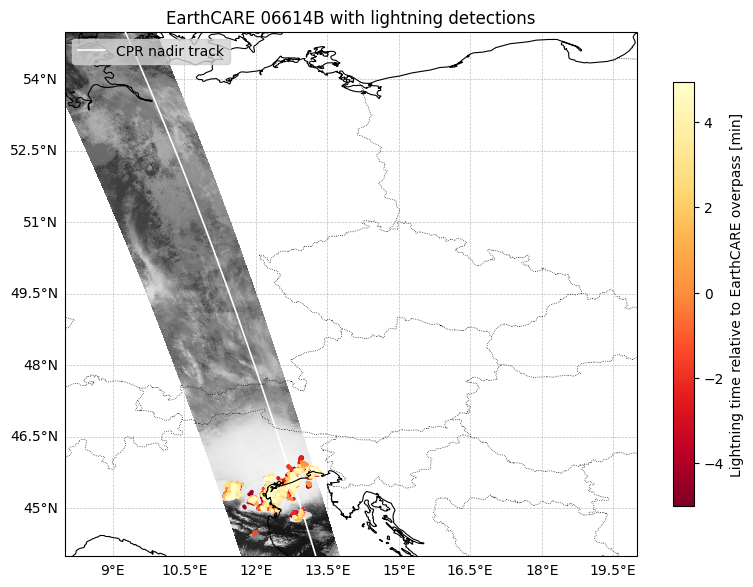

In [9]:
# --- MSI background ---
band = ds_msi["pixel_values"].sel(band='TIR2').values # 10.8 µm (VIS, VNIR, SWIR1, SWIR2, TIR1, TIR2, TIR3)
lat_msi = ds_msi["latitude"].values
lon_msi = ds_msi["longitude"].values
nodata = band.max()
valid = band < nodata
row_mask = valid.any(axis=1)
col_mask = valid[row_mask].any(axis=0)
band_clipped, lat_clipped, lon_clipped = [arr[np.ix_(row_mask, col_mask)] for arr in (band, lat_msi, lon_msi)]

# --- CPR track ---
lat_cpr = ds_cpr["latitude"].values
lon_cpr = ds_cpr["longitude"].values
valid_cpr = np.isfinite(lat_cpr) & np.isfinite(lon_cpr)

# --- Lightning data ---
lightning_gdf = lightning_gdf.sort_values("ec_time_diff", ascending=True)
lon_li = lightning_gdf.geometry.x.to_numpy()
lat_li = lightning_gdf.geometry.y.to_numpy()
time_li = lightning_gdf["ec_time_diff"] / np.timedelta64(1, "m")
valid_li = np.isfinite(lon_li) & np.isfinite(lat_li) & np.isfinite(time_li)

# --- Plot ---
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
minx, miny, maxx, maxy = ceurope_bbox.bounds
ax.set_extent([minx, maxx, miny, maxy], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--",)
gl.top_labels = False
gl.right_labels = False

ax.pcolormesh(lon_clipped, lat_clipped, band_clipped, cmap="Greys", transform=proj, zorder=2,)
ax.plot(lon_cpr[valid_cpr], lat_cpr[valid_cpr], color="white", linewidth=1.2, transform=proj, label="CPR nadir track", zorder=3,)
sc = ax.scatter(lon_li[valid_li], lat_li[valid_li], c=time_li[valid_li], cmap="YlOrRd_r", s=3, transform=proj, zorder=4,)

ax.set_title(f"EarthCARE {earthcare_id} with lightning detections")
ax.legend(loc="upper left", facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.55)
cbar.set_label("Lightning time relative to EarthCARE overpass [min]")

plt.tight_layout()
plt.show()

#### CPR reflectivity and lightning counts

Load the lightning track counts for the selected cluster within EarthCARE overpass. 

In [10]:
track_file = 'EC_track_lightning_LI.parquet'

track_gdf = gpd.read_parquet(
    f"{bucket}{prefix}{track_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    filters=[('earthcare_id', "==", earthcare_id),
             ("cluster_id", "==", cluster_id),],
)

CPR reflectivity along the EarthCARE nadir track, centered on the peak lightning location. Lightning counts are overlaid for comparison.

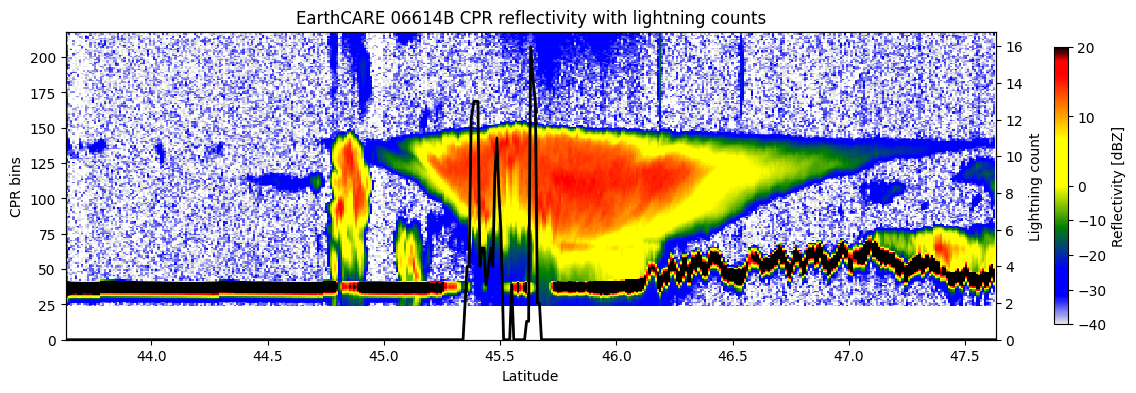

In [11]:
# --- setup ---
def define_cpr_cmap():
    import matplotlib.colors as mcolors
    colors = [
        (0.0, (0.9, 0.9, 0.9)), (0.1, 'blue'), (0.2, 'blue'),
        (0.35, 'green'), (0.5, 'yellow'), (0.67, 'yellow'),
        (0.9, 'red'), (0.95, 'red'), (1.0, 'black')
    ]
    return mcolors.LinearSegmentedColormap.from_list('cpr_cmap', colors)
cpr_cmap = define_cpr_cmap()
# set displayed latitude window around peak lightning
half_width = 2.0
desired_min, desired_max = peak_lat - half_width, peak_lat + half_width

# --- load CPR ---
lat = ds_cpr["latitude"].values
lat_dim = ds_cpr["latitude"].dims[0]
idx = np.where((lat >= desired_min) & (lat <= desired_max))[0]
da = ds_cpr["reflectivity_no_attenuation_correction"].isel({lat_dim: slice(idx[0], idx[-1] + 1)}).load()

lat_window = lat[idx[0]:idx[-1] + 1]
img = da.values if da.get_axis_num(lat_dim) != 0 else da.values.T
if lat_window[0] > lat_window[-1]:
    lat_window, img = lat_window[::-1], img[:, ::-1]

dx = np.median(np.diff(lat_window))
extent = [lat_window[0] - 0.5*dx, lat_window[-1] + 0.5*dx, 0, img.shape[0]]

# --- track lightning ---
order = np.argsort(track_gdf.geometry.y.values)
lat_track = track_gdf.geometry.y.values[order]
counts_track = track_gdf["lightning_count_2p5"].values[order]

# --- plot ---
fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(img, aspect="auto", cmap=cpr_cmap,
               norm=TwoSlopeNorm(vmin=-40, vcenter=0, vmax=20),
               extent=extent, origin="upper", interpolation="none")
ax.set(xlim=(desired_min, desired_max), xlabel="Latitude", ylabel="CPR bins",
       title=f"EarthCARE {earthcare_id} CPR reflectivity with lightning counts")

ax2 = ax.twinx()
ax2.plot(lat_track, counts_track, color="black", linewidth=2)
ax2.set(ylabel="Lightning count", ylim=(0, None))

plt.colorbar(im, ax=ax, shrink=0.9, pad=0.05).set_label("Reflectivity [dBZ]")
plt.show()